# Lab Day 1 — Notebook (PSEUDO-CODE)

> **Đây là khung pseudo-code.** Mọi ô có `# TODO` là phần bạn phải tự viết. Hãy giữ cấu trúc mục (Part 0–4) và
> viết dự đoán/nhận xét bằng chữ của bạn. Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess

MSSV = "2A202602870"
# Colab: mount Drive, vào đúng thư mục code/ của bản nộp để REPO_ROOT="../.." và import module chạy đúng.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    CODE_DIR = f"/content/drive/MyDrive/vinai_day1/K4-Track4-Day1-Neuralnetwork/submission_{MSSV}/code"
    os.chdir(CODE_DIR)
    sys.path.insert(0, CODE_DIR)
except ImportError:
    pass

import numpy as np, pandas as pd, torch

REPO_ROOT = "../.."     # thư mục gốc repo (chứa data/ và scripts/)
OUT_DIR   = ".."        # submission_<MSSV>/

device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", device, "|", torch.cuda.get_device_name(0) if device == "cuda" else "no GPU")
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)
print("cwd:", os.getcwd(), "| OUT_DIR ->", os.path.abspath(OUT_DIR))

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

Mounted at /content/drive
torch 2.11.0+cu130 | device: cuda | Tesla T4
cwd: /content/drive/MyDrive/vinai_day1/K4-Track4-Day1-Neuralnetwork/submission_2A202602870/code | OUT_DIR -> /content/drive/MyDrive/vinai_day1/K4-Track4-Day1-Neuralnetwork/submission_2A202602870


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [2]:
r = subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, capture_output=True, text=True)
print(r.stdout[-1500:], r.stderr[-1500:])
r.check_returncode()

data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")

X_tr = data["X_tr"]
mu, sd = X_tr[:, :10].mean(0), X_tr[:, :10].std(0)
print("mean 10 cột số:", mu.cpu().numpy().round(3))
print("std  10 cột số:", sd.cpu().numpy().round(3))
assert mu.abs().max() < 1e-3 and (sd - 1).abs().max() < 1e-3

train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data/processed/train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data/processed/eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876
 
X_tr (371847, 54) X_val (92962, 54) X_eval (116203, 54)
đoán lớp đa số trên val: 0.4876
mean 10 cột số: [ 0. -0.  0. -0. -0. -0.  0. -0.  0. -0.]
std  10 cột số: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

số tham số: 47879
Linear   -> (8, 256)
ReLU     -> (8, 256)
Dropout  -> (8, 256)
Linear   -> (8, 128)
ReLU     -> (8, 128)
Dropout  -> (8, 128)
Linear   -> (8, 7)
loss bước 0 = 2.3776  | ln 7 = 1.9459
std kích hoạt sau từng Linear: [0.6916343569755554, 0.656335175037384, 0.6535515189170837]
loss cuối = 0.00094 | acc 20 mẫu = 1.00


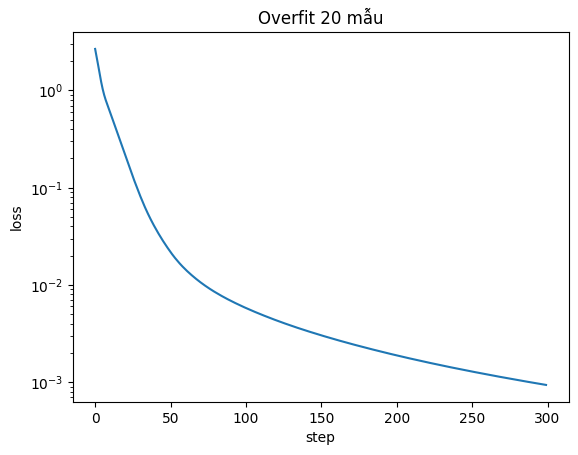

net.0.weight grad norm = 0.5977
net.0.bias   grad norm = 0.3876
net.3.weight grad norm = 2.3639
net.3.bias   grad norm = 0.5000
net.6.weight grad norm = 2.0773
net.6.bias   grad norm = 0.6064


In [3]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

Xtr, ytr, Xval, yval = data["X_tr"], data["y_tr"], data["X_val"], data["y_val"]
set_seed(42)

# 1) đúng kiến trúc và số tham số
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
assert count_params(model) == EXPECTED_PARAMS[(256, 128)]
print("số tham số:", count_params(model))

# 2) shape qua từng lớp (lá của cây module)
x = torch.randn(8, 54, device=device)
h = x
for layer in [m for m in model.modules() if not list(m.children())]:
    h = layer(h)
    print(f"{layer.__class__.__name__:8s} -> {tuple(h.shape)}")
assert model(x).shape == (8, 7)

# 3) loss bước 0 trên val (eval mode)
model.eval()
with torch.no_grad():
    loss0 = F.cross_entropy(model(Xval), yval).item()
print(f"loss bước 0 = {loss0:.4f}  | ln 7 = {np.log(7):.4f}")
print("std kích hoạt sau từng Linear:", activation_stats(model, Xval[:2048]))

# 4) quá khớp 20 mẫu, tắt dropout
m20 = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
opt = torch.optim.Adam(m20.parameters(), lr=1e-3)
x20, y20 = Xtr[:20], ytr[:20]
losses = []
m20.train()
for step in range(300):
    opt.zero_grad()
    loss = F.cross_entropy(m20(x20), y20)
    loss.backward()
    opt.step()
    losses.append(loss.item())
acc20 = (m20(x20).argmax(1) == y20).float().mean().item()
print(f"loss cuối = {losses[-1]:.5f} | acc 20 mẫu = {acc20:.2f}")
plt.plot(losses); plt.yscale("log"); plt.xlabel("step"); plt.ylabel("loss"); plt.title("Overfit 20 mẫu")
plt.savefig(f"{OUT_DIR}/results/part1_overfit20.png", dpi=120)   # ngoài figures/ (figures/ chỉ chứa ảnh theo exp_id)
plt.show()

# 5) gradient từng tham số sau một lần backward
model.train()
model.zero_grad()
F.cross_entropy(model(Xtr[:256]), ytr[:256]).backward()
for name, p in model.named_parameters():
    assert p.grad is not None and p.grad.norm() > 0, name
    print(f"{name:12s} grad norm = {p.grad.norm().item():.4f}")

**Nhận xét Part 1:** loss bước 0 đo được = 2.3776, còn ln 7 = 1.946. Số đo cao hơn ln 7 một chút. Nếu mạng đoán đều 7 lớp (xác suất 1/7 mỗi lớp) thì loss đúng bằng ln 7, nhưng với He init các logit ban đầu không bằng 0 mà có độ lệch chuẩn khoảng 1, nên mạng đang "tự tin sai" ở nhiều mẫu, làm loss lớn hơn ln 7. Mình thấy loss bước 0 đổi theo seed (1.90 / 1.98 / 2.27) nên đây là chuyện bình thường, không phải lỗi. Quá khớp 20 mẫu: loss giảm từ khoảng 2 xuống 0.00094 sau 300 bước và accuracy = 1.00, nghĩa là model, loss và vòng cập nhật đều đúng. Cả 6 tham số đều có gradient khác 0 (grad norm từ 0.39 đến 2.36), nên không có chỗ nào bị "đứt" gradient.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

In [4]:
# 1) Chọn lr cho baseline bằng VAL (sweep 10 epoch; không đụng eval)
sweep = {}
for lr in [0.003, 0.01, 0.03, 0.1, 0.2, 0.3, 0.5]:
    r = run_experiment({**DEFAULT_CFG, "lr": lr, "epochs": 10, "exp_id": f"lr-{lr}"}, data)
    sweep[lr] = r["summary"]
print(pd.DataFrame(sweep).T[["step0_loss", "best_val_loss", "val_acc", "val_macro_f1", "diverged"]])
LR = 0.2   # best_val_loss thấp nhất; F1 của 0.2 và 0.3 không phân biệt được trong nhiễu
print("lr chọn:", LR)

# 2) Baseline 3 seed, đủ 20 epoch
cfg = {**DEFAULT_CFG, "lr": LR}
base = []
for s in (1, 2, 3):
    r = run_experiment({**cfg, "seed": s, "exp_id": f"base-s{s}"}, data)
    save_result(r, f"{OUT_DIR}/results")
    plot_run(r, f"{OUT_DIR}/figures/base-s{s}.png")
    base.append(r)
    print(f"base-s{s}:", {k: round(v, 4) if isinstance(v, float) else v for k, v in r["summary"].items()})

# 3) Độ nhiễu giữa các seed
for m in ("val_macro_f1", "val_acc"):
    v = np.array([r["summary"][m] for r in base])
    print(f"{m}: {v.mean():.4f} ± {v.std(ddof=1):.4f}  (ngưỡng nhiễu 2σ = {2*v.std(ddof=1):.4f})")

      step0_loss best_val_loss   val_acc val_macro_f1 diverged
0.003   2.269082      0.486574  0.795927     0.623265    False
0.010   2.269082      0.382493  0.843043     0.718126    False
0.030   2.269082      0.325914  0.864375     0.742009    False
0.100   2.269082      0.289631  0.882834     0.806887    False
0.200   2.269082      0.270799  0.891031     0.825473    False
0.300   2.269082      0.271968  0.891751     0.827879    False
0.500   2.269082      0.275665  0.887653     0.821321    False
lr chọn: 0.2
base-s1: {'best_val_loss': 0.2289, 'best_epoch': 20, 'final_train_loss': 0.2033, 'final_val_loss': 0.2289, 'val_acc': 0.9086, 'val_macro_f1': 0.8549, 'time_per_epoch_s': 1.3216, 'step0_loss': 2.2691, 'diverged': False, 'peak_mem_MB': 173.4814}
base-s2: {'best_val_loss': 0.2167, 'best_epoch': 19, 'final_train_loss': 0.206, 'final_val_loss': 0.2304, 'val_acc': 0.9143, 'val_macro_f1': 0.8635, 'time_per_epoch_s': 1.5048, 'step0_loss': 1.9782, 'diverged': False, 'peak_mem_MB': 173.48

**Nhận xét baseline:** Mình chọn lr = 0.2 bằng cách thử vài lr trên val (0.003 đến 0.5), lr 0.2 và 0.3 cho kết quả gần như nhau còn 0.5 bắt đầu kém đi. Baseline 3 seed cho val acc 0.9125 ± 0.0035, cao hơn nhiều so với mốc "đoán lớp đa số" (0.4876), vậy mạng đã học được thật. Val macro-F1 = 0.8624 ± 0.0071, nên ngưỡng nhiễu 2σ = 0.0141: chênh lệch nhỏ hơn mức này mình không coi là bằng chứng. Đường cong val loss vẫn còn giảm nhẹ đến cuối (best epoch 19–20 trên 20), và khoảng cách val − train loss chỉ khoảng 0.025, nghĩa là mạng chưa học xong chứ chưa overfit. Grad norm gần như phẳng (0.39–0.44).

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

In [5]:
# Chạy một nhóm thí nghiệm: cfg baseline + CHỈ các khoá đổi. Lưu results/, figures/<exp_id>.png, figures/compare_<nhóm>.png
bf1 = np.array([r["summary"]["val_macro_f1"] for r in base])
base_mean_f1, noise_f1 = bf1.mean(), 2 * bf1.std(ddof=1)
all_results = {r["cfg"]["exp_id"]: r for r in base}     # Part 4 chọn cấu hình cuối từ đây (chỉ theo val)

def run_group(exps, group, metric="val_loss"):
    out = []
    for e in exps:
        ec = {**cfg, "group": group, **e}
        try:
            r = run_experiment(ec, data)
        except Exception as ex:
            print(f"BỎ QUA {ec['exp_id']}: {type(ex).__name__}: {ex}  -> ghi lý do vào cột notes")
            continue
        save_result(r, f"{OUT_DIR}/results")
        plot_run(r, f"{OUT_DIR}/figures/{ec['exp_id']}.png")
        out.append(r)
        all_results[ec["exp_id"]] = r
    rows = []
    for r in out:
        s = r["summary"]
        d = s["val_macro_f1"] - base_mean_f1
        rows.append(dict(exp_id=r["cfg"]["exp_id"], best_val_loss=s["best_val_loss"], best_epoch=s["best_epoch"],
                         val_acc=s["val_acc"], val_macro_f1=s["val_macro_f1"], d_f1_vs_base=d,
                         beyond_noise=bool(abs(d) > noise_f1), sec_per_ep=s["time_per_epoch_s"],
                         peak_MB=s["peak_mem_MB"], diverged=s["diverged"]))
    print(f"baseline: val_macro_f1 = {base_mean_f1:.4f}, ngưỡng nhiễu 2σ = {noise_f1:.4f}")
    if rows:
        print(pd.DataFrame(rows).round(4).to_string(index=False))
        plot_compare(out + [base[0]], metric, f"{OUT_DIR}/figures/compare_{group}.png", f"{group}: {metric}")
    return out

### Nhóm `optimizer`
**Dự đoán trước:** Mình đoán Adam sẽ học nhanh hơn SGD ở những epoch đầu vì nó tự chỉnh bước cho từng tham số. SGD thuần thì cần lr lớn hơn Adam rất nhiều (momentum 0.9 làm lr hiệu dụng của baseline khoảng 10 lần lr, nên SGD thuần phải thử lr cỡ 0.5–2). AdamW với weight decay nhỏ chắc gần giống Adam. Mình nghĩ nếu mỗi cái được chỉnh lr cho tốt thì kết quả chênh nhau không nhiều.

_Gợi ý: SGD thuần ở lr tương đương momentum khác gì? Adam cần lr cỡ nào? Adam vs AdamW khi wd>0?_

In [6]:
# SGD+momentum 0.9 với lr 0.2 có lr hiệu dụng ≈ 0.2/(1-0.9) = 2.0, nên SGD thuần thử lr 0.5 và 2.0.
opt_runs = run_group([
    dict(exp_id="opt-sgd-lr0.5",    description="SGD thuần, lr 0.5",  optimizer="sgd", lr=0.5),
    dict(exp_id="opt-sgd-lr2.0",    description="SGD thuần, lr 2.0",  optimizer="sgd", lr=2.0),
    dict(exp_id="opt-adam-lr3e-4",  description="Adam, lr 3e-4",      optimizer="adam", lr=3e-4),
    dict(exp_id="opt-adam-lr1e-3",  description="Adam, lr 1e-3",      optimizer="adam", lr=1e-3),
    dict(exp_id="opt-adam-lr3e-3",  description="Adam, lr 3e-3",      optimizer="adam", lr=3e-3),
    dict(exp_id="opt-adamw-lr1e-3", description="AdamW, lr 1e-3, wd 0.01", optimizer="adamw", lr=1e-3, weight_decay=0.01),
], "optimizer")

baseline: val_macro_f1 = 0.8624, ngưỡng nhiễu 2σ = 0.0141
          exp_id  best_val_loss  best_epoch  val_acc  val_macro_f1  d_f1_vs_base  beyond_noise  sec_per_ep  peak_MB  diverged
   opt-sgd-lr0.5         0.2598          19   0.8944        0.8311       -0.0313          True      1.3157 173.6646     False
   opt-sgd-lr2.0         0.2781          15   0.8894        0.8220       -0.0405          True      1.2962 173.8477     False
 opt-adam-lr3e-4         0.3127          20   0.8729        0.7878       -0.0747          True      1.4681 174.3970     False
 opt-adam-lr1e-3         0.2443          18   0.9021        0.8446       -0.0179          True      1.4663 174.5801     False
 opt-adam-lr3e-3         0.2169          19   0.9136        0.8702        0.0078         False      1.4449 174.7632     False
opt-adamw-lr1e-3         0.2487          18   0.9002        0.8403       -0.0222          True      1.4699 174.9463     False


**Đối chiếu `optimizer`:** Khớp một phần với dự đoán. Adam lr 1e-3 (0.8446) và AdamW (0.8403) thấp hơn baseline vượt nhiễu, nhưng khi tăng lr lên 3e-3 thì Adam đạt 0.8702, hơn baseline +0.0078, tức là chưa vượt ngưỡng 2σ = 0.0141. Vậy khi chỉnh lr cho công bằng thì chênh nhau không nhiều, đúng như mình đoán, còn Adam "thua" ở lr mặc định chỉ vì lr chưa chỉnh. SGD thuần lr 0.1 / 0.5 / 2.0 cho 0.755 / 0.831 / 0.822, tốt nhất ở 0.5 và lr 2.0 dao động mạnh giữa các epoch (xem ảnh). (SGD lr 0.1 chạy ở một lần chạy trước của cùng notebook nên không có trong ô output ở trên, kết quả vẫn nằm trong `results/opt-sgd-lr0.1.json`.) AdamW chỉ khác Adam −0.004 vì weight decay 0.01 × lr 1e-3 = 1e-5 mỗi bước là quá nhỏ để thấy khác biệt.

### Nhóm `hparam`
**Dự đoán trước:** Mình đoán baseline chưa học xong trong 20 epoch (best epoch gần cuối), nên tăng lên 40 epoch sẽ tốt hơn. Mạng rộng hơn (512-256) cũng nên tốt hơn một chút. Batch lớn (2048) chạy nhanh hơn mỗi epoch nhưng ít bước cập nhật hơn nên có thể kém hơn, nhân lr lên 4 lần có thể cứu được. Batch nhỏ (128) chậm hơn mà chưa chắc tốt hơn.

_Gợi ý: baseline chưa hội tụ (best epoch ≈ 20): tăng epoch có giúp? batch lớn ít bước hơn, cần tăng lr? rộng/sâu hơn có đáng?_

In [7]:
hp_runs = run_group([
    dict(exp_id="hp-ep40",        description="40 epoch (baseline 20)", epochs=40),
    dict(exp_id="hp-b128",        description="batch 128", batch=128),
    dict(exp_id="hp-b2048",       description="batch 2048, giữ lr", batch=2048),
    dict(exp_id="hp-b2048-lr0.8", description="batch 2048, lr x4", batch=2048, lr=0.8),
    dict(exp_id="hp-wide",        description="M-wide 512-256", hidden=(512, 256)),
    dict(exp_id="hp-deep",        description="M-deep 256-128-64", hidden=(256, 128, 64)),
], "hparam")

baseline: val_macro_f1 = 0.8624, ngưỡng nhiễu 2σ = 0.0141
        exp_id  best_val_loss  best_epoch  val_acc  val_macro_f1  d_f1_vs_base  beyond_noise  sec_per_ep  peak_MB  diverged
       hp-ep40         0.1957          37   0.9237        0.8770        0.0146          True      1.3128 174.9463     False
       hp-b128         0.2662          15   0.8981        0.8236       -0.0388          True      5.2261 175.1021     False
      hp-b2048         0.2498          20   0.8992        0.8320       -0.0305          True      0.3455 175.5312     False
hp-b2048-lr0.8         0.2625          20   0.8952        0.8263       -0.0361          True      0.3377 175.7144     False
       hp-wide         0.1982          20   0.9222        0.8772        0.0148          True      1.3431 192.4644     False
       hp-deep         0.2081          20   0.9181        0.8572       -0.0053         False      1.4825 176.4155     False


**Đối chiếu `hparam`:** Đúng một phần. 40 epoch (+0.0146) và mạng rộng (+0.0148) đều tốt hơn baseline, nhưng chỉ vừa sát ngưỡng 2σ = 0.0141 và mới chạy 1 seed nên kết luận còn yếu. Mạng sâu (256-128-64) không khác baseline (−0.0053, trong nhiễu). Batch 2048 nhanh gấp khoảng 4 lần mỗi epoch (0.35 giây so với 1.3 giây) nhưng kém hơn (−0.0305) vì chỉ còn 1/4 số bước cập nhật. Khác với dự đoán: nhân lr lên ×4 (0.8) không cứu được (0.8263), có lẽ vì lr 0.8 với momentum 0.9 đã quá lớn. Batch 128 chậm gấp 4 lần (5.2 giây/epoch) mà kém hơn (−0.0388). Thời gian mỗi epoch của mạng rộng gần như không đổi (1.34 giây) vì GPU chưa bị đầy.

### Nhóm `dropout`
**Dự đoán trước:** Mình đoán dropout sẽ không giúp, vì baseline có train loss ≈ val loss (gap chỉ khoảng 0.025) nên chưa overfit. Thêm dropout chỉ làm mạng khó học hơn, nên macro-F1 sẽ giảm, và giảm nhiều hơn khi dropout 0.3.

_Gợi ý: baseline chưa quá khớp (train≈val): dropout có chắc giúp?_

In [8]:
drop_runs = run_group([
    dict(exp_id="drop-0.1", description="dropout 0.1", dropout=0.1),
    dict(exp_id="drop-0.3", description="dropout 0.3", dropout=0.3),
], "dropout")

baseline: val_macro_f1 = 0.8624, ngưỡng nhiễu 2σ = 0.0141
  exp_id  best_val_loss  best_epoch  val_acc  val_macro_f1  d_f1_vs_base  beyond_noise  sec_per_ep  peak_MB  diverged
drop-0.1         0.2419          20   0.9013        0.8426       -0.0198          True      1.4063 176.5078     False
drop-0.3         0.3109          20   0.8749        0.7921       -0.0703          True      1.4109 176.6909     False


**Đối chiếu `dropout`:** Khớp dự đoán. Dropout 0.1 giảm macro-F1 0.020 và dropout 0.3 giảm 0.070, cả hai vượt ngưỡng nhiễu 0.0141. Khoảng cách val − train loss đúng là nhỏ lại (0.026 → 0.012 → 0.007), nhưng vì mạng chưa overfit nên thu hẹp khoảng cách này không có lợi gì: train loss còn tăng lên (0.203 → 0.230 → 0.304). Mình rút ra: dropout chỉ nên dùng khi val loss bắt đầu tăng trong lúc train loss vẫn giảm.

### Nhóm `loss`
**Dự đoán trước:** Mình đoán MSE trên one-hot sẽ kém cross-entropy: gradient nhỏ hơn nên học chậm hơn, và các lớp hiếm sẽ bị bỏ qua nhiều hơn. Giá trị loss của hai cách khác thang đo nên mình sẽ chỉ so accuracy và macro-F1.

_Gợi ý: gradient của CE và MSE khi dự đoán sai nặng khác nhau thế nào?_

In [9]:
# MSE trên one-hot; thang loss khác CE nên so macro-F1, không so giá trị loss.
loss_runs = run_group([
    dict(exp_id="loss-mse", description="MSE trên one-hot (thay cross-entropy)", loss="mse"),
], "loss", metric="val_macro_f1")

baseline: val_macro_f1 = 0.8624, ngưỡng nhiễu 2σ = 0.0141
  exp_id  best_val_loss  best_epoch  val_acc  val_macro_f1  d_f1_vs_base  beyond_noise  sec_per_ep  peak_MB  diverged
loss-mse         0.0272          20   0.8819        0.7816       -0.0808          True      1.3722 176.8774     False


**Đối chiếu `loss`:** Khớp dự đoán. MSE cho macro-F1 0.7816, thấp hơn baseline 0.081 (rất xa 2σ). Giá trị loss của MSE (0.027) nhỏ hơn CE (0.229) nhưng không so được vì khác thang đo. Lý do mình thấy: grad norm của MSE chỉ 0.06–0.08, trong khi CE là khoảng 0.40, nên MSE học chậm như đang dùng lr nhỏ hơn nhiều (best epoch = 20, đường cong còn đang đi xuống). Ngoài ra MSE chia trung bình cho cả 7 cột nên gradient nhỏ hơn nữa, các lớp hiếm bị ảnh hưởng nhiều hơn.

### Nhóm `clipping`
**Dự đoán trước:** Mình đoán ở lr bình thường clipping gần như không đổi kết quả, vì grad norm của baseline khá phẳng. Ở lr rất cao (1.0, 2.0) không clip thì huấn luyện sẽ hỏng hoặc rất dao động, còn có clip thì ổn định hơn nhưng chưa chắc bằng baseline.

_Gợi ý: grad_norm baseline ≈ 0.4: clip ở c nhỏ hơn thay đổi gì? ở lr rất lớn, clip có cứu được không?_

In [10]:
gn_base = float(np.mean([np.mean(r["history"]["grad_norm"]) for r in base]))
C = round(0.7 * gn_base, 2)      # nhỏ hơn grad_norm trung bình -> clipping thực sự kích hoạt
print(f"grad_norm trung bình baseline = {gn_base:.3f} -> ngưỡng clip c = {C}")
clip_runs = run_group([
    dict(exp_id=f"clip-{C}",         description=f"clip_norm={C}, lr baseline", clip_norm=C),
    dict(exp_id="clip-hi1.0-noclip", description="lr 1.0 (5x), không clip", lr=1.0),
    dict(exp_id="clip-hi1.0-clip",   description=f"lr 1.0 (5x), clip_norm={C}", lr=1.0, clip_norm=C),
    dict(exp_id="clip-hi2.0-noclip", description="lr 2.0 (10x), không clip", lr=2.0),
    dict(exp_id="clip-hi2.0-clip",   description=f"lr 2.0 (10x), clip_norm={C}", lr=2.0, clip_norm=C),
], "clipping")

grad_norm trung bình baseline = 0.410 -> ngưỡng clip c = 0.29
baseline: val_macro_f1 = 0.8624, ngưỡng nhiễu 2σ = 0.0141
           exp_id  best_val_loss  best_epoch  val_acc  val_macro_f1  d_f1_vs_base  beyond_noise  sec_per_ep  peak_MB  diverged
        clip-0.29         0.2377          20   0.9061        0.8551       -0.0074         False      1.3214 177.0571     False
clip-hi1.0-noclip         0.3446          16   0.8618        0.7775       -0.0849          True      1.3200 177.2402     False
  clip-hi1.0-clip         0.2872          14   0.8870        0.8244       -0.0380          True      1.3712 177.4233     False
clip-hi2.0-noclip         1.2060           2   0.4876        0.0936       -0.7688          True      1.3264 177.6064     False
  clip-hi2.0-clip         0.5492          17   0.7790        0.5994       -0.2630          True      1.3350 177.7896     False


**Đối chiếu `clipping`:** Khớp dự đoán. Mình chọn c = 0.29 (nhỏ hơn grad norm trung bình 0.41) để clipping thật sự kích hoạt. Ở lr bình thường kết quả gần như không đổi (0.8551, −0.0074, trong nhiễu). Ở lr 2.0 không clip, mạng sụp về đoán lớp đa số (acc 0.4876, F1 0.094, loss kẹt khoảng 1.21), còn có clip thì F1 lên 0.599, tức là cứu được phần lớn nhưng chưa bằng baseline. Ở lr 1.0, clip nâng F1 từ 0.778 lên 0.824 (vượt nhiễu). Mình hiểu clipping chỉ giới hạn độ dài bước, còn lr quá cao thì vẫn làm hội tụ kém. Lưu ý: grad_norm in ra là trung bình mỗi epoch trước khi clip nên không thấy từng lần tăng đột biến.

### Nhóm `amp`
**Dự đoán trước:** Mình đoán mạng này quá nhỏ (48k tham số) nên mixed precision sẽ không nhanh hơn, có thể còn chậm hơn vì tốn thêm bước đổi kiểu số. Độ chính xác chắc không đổi nhiều. FP16 cần GradScaler còn BF16 thì không.

_Gợi ý: mạng nhỏ (48k tham số): FP16 có nhanh hơn thật không? độ chính xác có đổi?_

In [11]:
bf16_ok = device == "cuda" and torch.cuda.is_bf16_supported()
print("bf16 hỗ trợ:", bf16_ok)
amp_exps = [dict(exp_id="amp-fp16", description="mixed precision FP16 + GradScaler", precision="fp16")]
if bf16_ok:
    amp_exps.append(dict(exp_id="amp-bf16", description="mixed precision BF16", precision="bf16"))
else:
    print("GPU không hỗ trợ BF16 phần cứng (vd T4): bỏ amp-bf16, ghi lý do vào báo cáo.")
amp_runs = run_group(amp_exps, "amp")

bf16 hỗ trợ: True
baseline: val_macro_f1 = 0.8624, ngưỡng nhiễu 2σ = 0.0141
  exp_id  best_val_loss  best_epoch  val_acc  val_macro_f1  d_f1_vs_base  beyond_noise  sec_per_ep  peak_MB  diverged
amp-fp16         0.2332          20   0.9089        0.8463       -0.0162          True      1.7937 177.9736     False
amp-bf16         0.2201          20   0.9139        0.8570       -0.0054         False      1.5859 178.1558     False


**Đối chiếu `amp`:** Khớp dự đoán, thậm chí chậm hơn mình nghĩ: FP32 mất 1.32 giây/epoch, BF16 1.59 giây, FP16 1.79 giây. Bộ nhớ cực đại gần như như nhau (173 so với 178 MB) vì dữ liệu nằm sẵn trên GPU và mạng rất nhỏ. Mạng nhỏ nên thời gian bị chi phối bởi việc gọi kernel và đổi kiểu số, chứ không phải phép nhân ma trận mà Tensor Core giúp tăng tốc. Độ chính xác không đổi đáng kể (FP16 0.8463, BF16 0.8570 so với 0.8549 của cùng seed 1, đều trong nhiễu). FP16 cần GradScaler vì phạm vi số nhỏ nên gradient dễ bị làm tròn về 0, còn BF16 có cùng phạm vi mũ với FP32 nên thường không cần.

### Nhóm `init`
**Dự đoán trước:** Mình đoán zeros sẽ hỏng hoàn toàn vì mọi nơ-ron giống hệt nhau. Normal std 0.01 làm kích hoạt nhỏ dần qua từng lớp nên học chậm hoặc kém. Xavier và He chắc ngang nhau vì mạng chỉ có 3 lớp.

_Gợi ý: zeros làm gì với gradient lớp đầu? normal 0.01 làm kích hoạt co lại thế nào? Xavier vs He với ReLU?_

In [12]:
for name in ("zeros", "normal", "xavier", "he", "default"):
    set_seed(0)
    m = MLP(hidden=(256, 128), init=name).to(device)
    print(f"{name:8s} std kích hoạt sau từng Linear (bước 0):", activation_stats(m, data["X_val"][:2048]))
init_runs = run_group([
    dict(exp_id=f"init-{n}", description=f"khởi tạo {n}", init=n) for n in ("zeros", "normal", "xavier", "default")
], "init")

zeros    std kích hoạt sau từng Linear (bước 0): [0.0, 0.0, 0.0]
normal   std kích hoạt sau từng Linear (bước 0): [0.03395356982946396, 0.003972597885876894, 0.0002896389923989773]
xavier   std kích hoạt sau từng Linear (bước 0): [0.27272164821624756, 0.2302810251712799, 0.2043566107749939]
he       std kích hoạt sau từng Linear (bước 0): [0.6534367203712463, 0.6757526993751526, 0.6158574223518372]
default  std kích hoạt sau từng Linear (bước 0): [0.28513768315315247, 0.12123165279626846, 0.07245362550020218]
baseline: val_macro_f1 = 0.8624, ngưỡng nhiễu 2σ = 0.0141
      exp_id  best_val_loss  best_epoch  val_acc  val_macro_f1  d_f1_vs_base  beyond_noise  sec_per_ep  peak_MB  diverged
  init-zeros         1.2052          12   0.4876        0.0936       -0.7688          True      1.3168 178.5220     False
 init-normal         0.2218          18   0.9114        0.8547       -0.0077         False      1.3679 178.7051     False
 init-xavier         0.2122          20   0.9147        0.865

**Đối chiếu `init`:** Đúng với `zeros`, khác một chút với `normal`. `zeros` hỏng hoàn toàn (F1 0.094, acc 0.4876): các nơ-ron giống hệt nhau, đầu ra ReLU bằng 0 nên gradient của các lớp dưới bằng 0, chỉ bias lớp cuối học được, mạng chỉ biết tần suất từng lớp. `normal` (std 0.01): độ lệch chuẩn kích hoạt co khoảng 10 lần mỗi lớp (0.034 → 0.004 → 0.0003) và loss bước 0 = 1.946 = ln 7, nhưng bất ngờ là mạng vẫn học được (0.8547). Mình đoán là vì chỉ có 3 lớp nên học lại được; mạng sâu hơn thì chắc sẽ không được. Xavier (0.8653), default (0.8550) và He (0.8549) chênh nhau trong nhiễu. He giữ độ lệch chuẩn khoảng 0.65 qua các lớp, còn Xavier giảm dần (0.27 → 0.20) vì ReLU triệt một nửa phương sai; sự khác này chỉ quan trọng khi mạng sâu.

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [13]:
def eval_pred(pred_csv, out_json):
    r = subprocess.run([sys.executable, "scripts/evaluate.py", "--pred", os.path.abspath(pred_csv),
                        "--out", os.path.abspath(out_json)], cwd=REPO_ROOT, capture_output=True, text=True)
    print(r.stdout, r.stderr)
    r.check_returncode()
    return json.load(open(out_json))

# Chọn cấu hình cuối CHỈ theo val_macro_f1 (winner's curse: chọn tốt nhất trong nhiều lần chạy hơi lạc quan -> nêu trong báo cáo)
cands = [r for r in all_results.values() if not r["summary"]["diverged"]]
final = max(cands, key=lambda r: r["summary"]["val_macro_f1"])
fid = final["cfg"]["exp_id"]
print("cấu hình cuối:", fid, "| val_macro_f1 =", round(final["summary"]["val_macro_f1"], 4))

import tempfile
tmp = tempfile.gettempdir()
final_eval(final["cfg"], final, data, f"{OUT_DIR}/predictions_eval.csv")
ev_final = eval_pred(f"{OUT_DIR}/predictions_eval.csv", f"{OUT_DIR}/eval_result.json")

final_eval(base[0]["cfg"], base[0], data, os.path.join(tmp, "predictions_baseline.csv"))
ev_base = eval_pred(os.path.join(tmp, "predictions_baseline.csv"), os.path.join(tmp, "eval_baseline.json"))
print(f"baseline eval: acc={ev_base['accuracy']:.4f} F1={ev_base['macro_f1']:.4f} | cuối ({fid}): acc={ev_final['accuracy']:.4f} F1={ev_final['macro_f1']:.4f}")

cấu hình cuối: hp-wide | val_macro_f1 = 0.8772
n_eval = 116203
accuracy = 0.9217
macro_f1 = 0.8799   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9239  0.9142  0.9190
  1    56661     0.9315  0.9365  0.9340
  2     7151     0.8902  0.9457  0.9171
  3      549     0.8926  0.7869  0.8364
  4     1899     0.7747  0.8004  0.7874
  5     3473     0.8844  0.7910  0.8351
  6     4102     0.9239  0.9376  0.9307

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  38732   3292     1    0    66     2   275
1   2937  53064   169    0   357    92    42
2      0    117  6763   32    12   227     0
3      0      0    93  432     0    24     0
4     26    304    35    0  1520    14     0
5     17    146   536   20     7  2747     0
6    212     44     0    0     0     0  3846
 
n_eval = 116203
accuracy = 0.9217
macro_f1 = 0.8799   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9239  0.9142  0.9190
  1  

In [14]:
names = ["Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine", "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"]
pc = pd.DataFrame(ev_final["per_class"])
pc.insert(1, "name", names)
print(pc.round(4).to_string(index=False))
cm = np.array(ev_final["confusion_matrix"])
print("\nma trận nhầm lẫn (hàng = thật, cột = dự đoán):")
print(pd.DataFrame(cm, index=names, columns=range(7)).to_string())
print("\nrecall theo hàng:")
print(pd.DataFrame(cm / cm.sum(1, keepdims=True), index=names, columns=range(7)).round(3).to_string())
off = cm.copy(); np.fill_diagonal(off, 0)
print("\n5 kiểu nhầm nhiều nhất:")
for t, p in zip(*np.unravel_index(np.argsort(-off.ravel())[:5], off.shape)):
    print(f"  thật {names[t]} -> đoán {names[p]}: {off[t, p]} mẫu")

 cls              name  support  precision  recall     f1
   0        Spruce/Fir    42368     0.9239  0.9142 0.9190
   1    Lodgepole Pine    56661     0.9315  0.9365 0.9340
   2    Ponderosa Pine     7151     0.8902  0.9457 0.9171
   3 Cottonwood/Willow      549     0.8926  0.7869 0.8364
   4             Aspen     1899     0.7747  0.8004 0.7874
   5       Douglas-fir     3473     0.8844  0.7910 0.8351
   6         Krummholz     4102     0.9239  0.9376 0.9307

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
                       0      1     2    3     4     5     6
Spruce/Fir         38732   3292     1    0    66     2   275
Lodgepole Pine      2937  53064   169    0   357    92    42
Ponderosa Pine         0    117  6763   32    12   227     0
Cottonwood/Willow      0      0    93  432     0    24     0
Aspen                 26    304    35    0  1520    14     0
Douglas-fir           17    146   536   20     7  2747     0
Krummholz            212     44     0    0     0     0  3846


**Phân tích lỗi:** Cấu hình cuối (`hp-wide`) cho eval macro-F1 = 0.8799 và accuracy = 0.9217. Lớp khó nhất là lớp 4 (Aspen) với F1 = 0.787 và precision 0.775: khoảng 16% mẫu Aspen bị đoán thành Lodgepole Pine (304 trên 1 899 mẫu). Hai lớp 0 (Spruce/Fir) và 1 (Lodgepole Pine) nhầm nhau nhiều nhất về số lượng (3 292 và 2 937 mẫu), vì hai lớp này chiếm khoảng 85% dữ liệu và đặc trưng địa hình khá giống nhau. Lớp 3 (Cottonwood/Willow) chỉ có 549 mẫu (0.47%) nên recall thấp (0.787), 17% bị nhầm sang lớp 2 (Ponderosa Pine); Douglas-fir cũng hay bị nhầm với Ponderosa Pine (536 mẫu). Mình nghĩ các lớp hiếm khó hơn vì có ít mẫu để học và đặc trưng chồng lấn với lớp gần. Lần sau mình sẽ thử class-weighted loss hoặc train lâu hơn.

In [15]:
results = load_results(f"{OUT_DIR}/results")
eval_map = {base[0]["cfg"]["exp_id"]: dict(eval_acc=ev_base["accuracy"], eval_macro_f1=ev_base["macro_f1"]),
            fid: dict(eval_acc=ev_final["accuracy"], eval_macro_f1=ev_final["macro_f1"])}   # chỉ baseline và cấu hình cuối
rows = []
for r in results:
    i = r["cfg"]["exp_id"]
    rows.append(to_row(r, eval_map.get(i), notes="cấu hình cuối (chọn theo val_macro_f1)" if i == fid else ""))
out_xlsx = f"{OUT_DIR}/experiments.xlsx"
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", out_xlsx)

import openpyxl
wb = openpyxl.load_workbook(out_xlsx)
for i, r in enumerate(base, start=2):
    wb["Seeds"].cell(row=i, column=1, value=r["cfg"]["exp_id"])
wb.save(out_xlsx)
print("đã ghi", out_xlsx, "|", len(rows), "dòng. Mở bằng Excel để công thức tính lại; viết nhận xét ở sheet Summary.")

ids = [r["cfg"]["exp_id"] for r in results]
pngs = {f[:-4] for f in os.listdir(f"{OUT_DIR}/figures") if f.endswith(".png")}
print("thiếu ảnh:", [i for i in ids if i not in pngs])
print("ảnh thừa :", sorted(p for p in pngs if p not in ids and not p.startswith("compare_")))

đã ghi ../experiments.xlsx | 30 dòng. Mở bằng Excel để công thức tính lại; viết nhận xét ở sheet Summary.
thiếu ảnh: []
ảnh thừa : ['part1_overfit20']
